In [28]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import norm, binom
from matplotlib import pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc, Patch 
import os

Loading the dataframe

In [29]:
shots=pd.read_csv(os.path.join("data","shots_all_seasons.csv"), low_memory=False)

shots.head()


,SEASON_1,SEASON_2,TEAM_ID,TEAM_NAME,PLAYER_ID,PLAYER_NAME,POSITION_GROUP,POSITION,GAME_DATE,GAME_ID,...,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT
0,2004,2003-04,1610612747,Los Angeles Lakers,977,Kobe Bryant,G,SG,04-14-2004,20301187,...,Above the Break 3,Left Side Center,LC,24+ ft.,20.0,21.35,25,6,0,0
1,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,6,0,2
2,2004,2003-04,1610612747,Los Angeles Lakers,977,Kobe Bryant,G,SG,04-14-2004,20301187,...,Mid-Range,Left Side Center,LC,16-24 ft.,13.3,24.45,23,6,0,9
3,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Mid-Range,Left Side,L,16-24 ft.,16.4,13.95,18,6,0,31
4,2004,2003-04,1610612757,Portland Trail Blazers,757,Damon Stoudamire,G,PG,04-14-2004,20301187,...,Mid-Range,Right Side,R,16-24 ft.,-15.8,7.85,16,6,0,55


In [30]:
shots.tail()

,SEASON_1,SEASON_2,TEAM_ID,TEAM_NAME,PLAYER_ID,PLAYER_NAME,POSITION_GROUP,POSITION,GAME_DATE,GAME_ID,...,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT
4450784,2025,2024-25,1610612764,Washington Wizards,1629673,Jordan Poole,NaN,NaN,12-15-2024,22401217,...,Restricted Area,Center,C,Less Than 8 ft.,-1.5,5.35,1,4,3,14
4450785,2025,2024-25,1610612764,Washington Wizards,1629673,Jordan Poole,NaN,NaN,12-15-2024,22401217,...,Above the Break 3,Right Side Center,RC,24+ ft.,-18.3,31.95,32,4,2,53
4450786,2025,2024-25,1610612764,Washington Wizards,1642259,Alex Sarr,NaN,NaN,12-15-2024,22401217,...,Right Corner 3,Right Side,R,24+ ft.,-22.9,8.45,23,4,2,11
4450787,2025,2024-25,1610612764,Washington Wizards,1630551,Justin Champagnie,NaN,NaN,12-15-2024,22401217,...,Restricted Area,Center,C,Less Than 8 ft.,0.7,6.65,1,4,1,45
4450788,2025,2024-25,1610612764,Washington Wizards,1629673,Jordan Poole,NaN,NaN,12-15-2024,22401217,...,Restricted Area,Center,C,Less Than 8 ft.,-1.7,6.95,2,4,1,20


Plotting the court for visual examples

<Axes: >

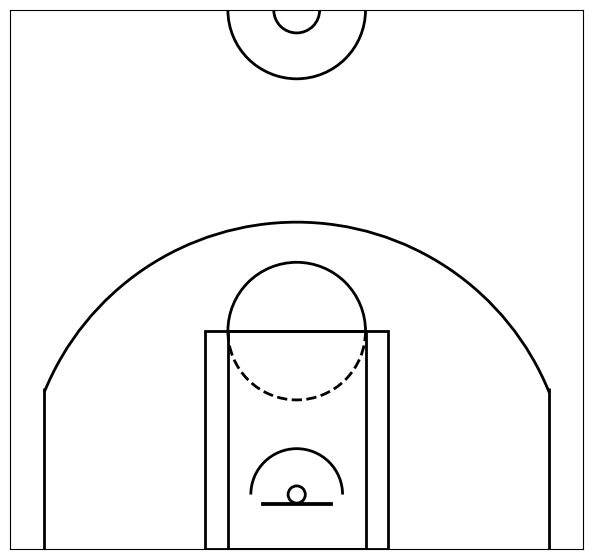

In [31]:

fig, ax = plt.subplots(figsize=(10, 7))
def draw_court(ax=None, color='black', lw=2, outer_lines=False, interval=20):
    if ax is None:
        ax = plt.gca()

    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color, fill=False)
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
    center_outer_arc = Arc((0, 422.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0, linewidth=lw, color=color)
    court_elements = [hoop, backboard, outer_box, inner_box, top_free_throw,
                    bottom_free_throw, restricted, corner_three_a,
                    corner_three_b, three_arc, center_outer_arc,
                    center_inner_arc]

    if outer_lines:
        outer_lines = Rectangle((-250, -47.5), 500, 470, linewidth=lw,color=color, fill=False)
        court_elements.append(outer_lines)

    for element in court_elements:
        ax.add_patch(element)

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-250, 250)
    ax.set_ylim(-47.5, 422.5)
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

draw_court(ax)

Analyzed season played by said player

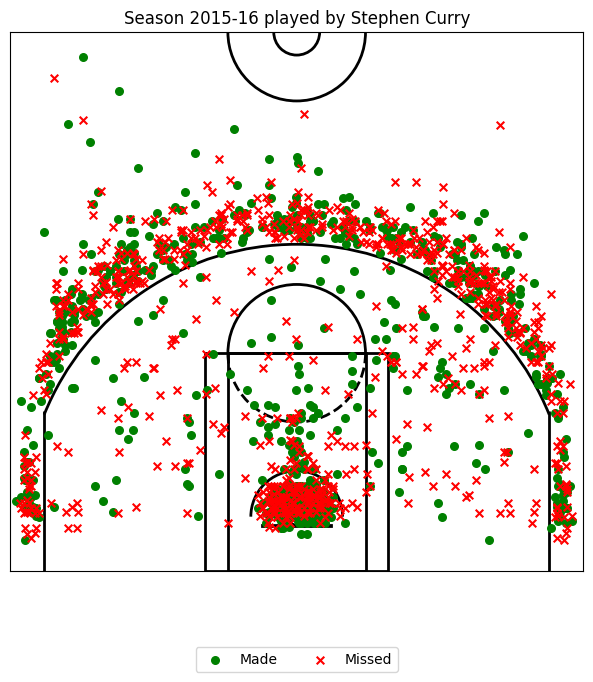

In [32]:
player = 'Stephen Curry'
season = 2016
shotsfiltered=shots[
    (shots['SEASON_1'] == season) & 
    (shots['PLAYER_NAME'] == player) &
    (shots['SHOT_DISTANCE'] >=0)
]

made_shots = shotsfiltered[shotsfiltered['SHOT_MADE'] == True]
missed_shots = shotsfiltered[shotsfiltered['SHOT_MADE'] == False]

completeseason = (shotsfiltered['SEASON_2']).iloc[0]

fig, ax = plt.subplots(figsize=(10, 7))

draw_court(ax)

offset=51.7

ax.scatter(made_shots['LOC_X'] * -10 , made_shots['LOC_Y'] * 10 - offset, 
                    color='green', label='Made', s=30)
ax.scatter(missed_shots['LOC_X'] * -10 , missed_shots['LOC_Y'] * 10 - offset, 
                    color='red', label='Missed', marker='x', s=30)


ax.set_title(f"Season {completeseason} played by {player}")
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=2)


plt.show()

In [33]:
distanzefiltered = np.sqrt(shotsfiltered['LOC_X']**2 + shotsfiltered['LOC_Y']**2)

distanze=distanzefiltered[distanzefiltered<45] #shot before half court

mean = np.mean(distanze)
mode = stats.mode(np.round(distanze), keepdims=True).mode[0] 
varianza = np.var(distanze)
dev_std = np.std(distanze) 
min = np.min(distanze)
max = np.max(distanze)

Gaussian distribution comparison

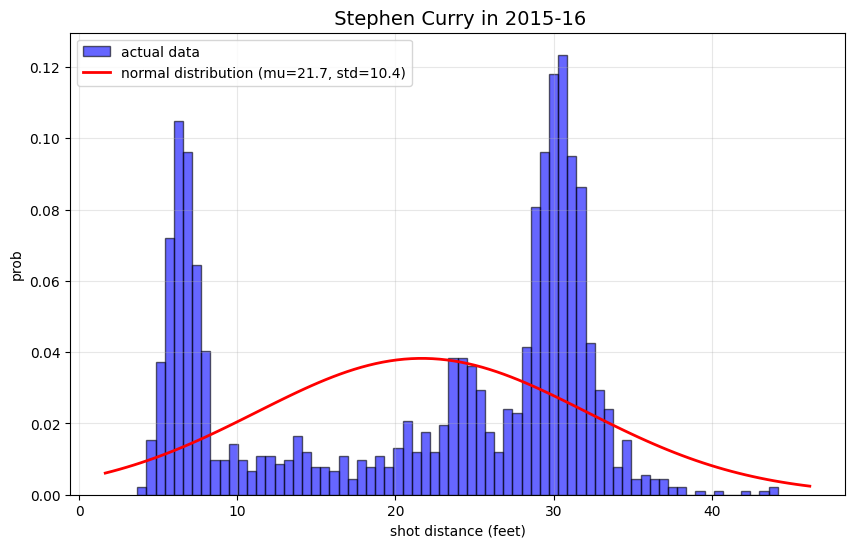

It's almost impossible to get a gaussian normal with basketball shots data as they do not depend on a trend but vary from playerstyles and basketball dynamics


In [34]:
plt.figure(figsize=(10, 6))

plt.hist(distanze, bins=70, density=True, alpha=0.6, color='blue', edgecolor='black', label="actual data")

xmin, xmax = plt.xlim() #saving axes limits

#bell curve generation
x = np.linspace(xmin, xmax, 100) 
p = norm.pdf(x, mean, dev_std) 

plt.plot(x, p, 'r', linewidth=2, label=f'normal distribution (mu={mean:.1f}, std={dev_std:.1f})')

plt.title(f' {player} in {completeseason}', fontsize=14)
plt.xlabel('shot distance (feet)')
plt.ylabel('prob')
plt.legend()
plt.grid(alpha=0.3)

plt.show()
print("It's almost impossible to get a gaussian normal with basketball shots data as they do not depend on a trend but vary from playerstyles and basketball dynamics" )

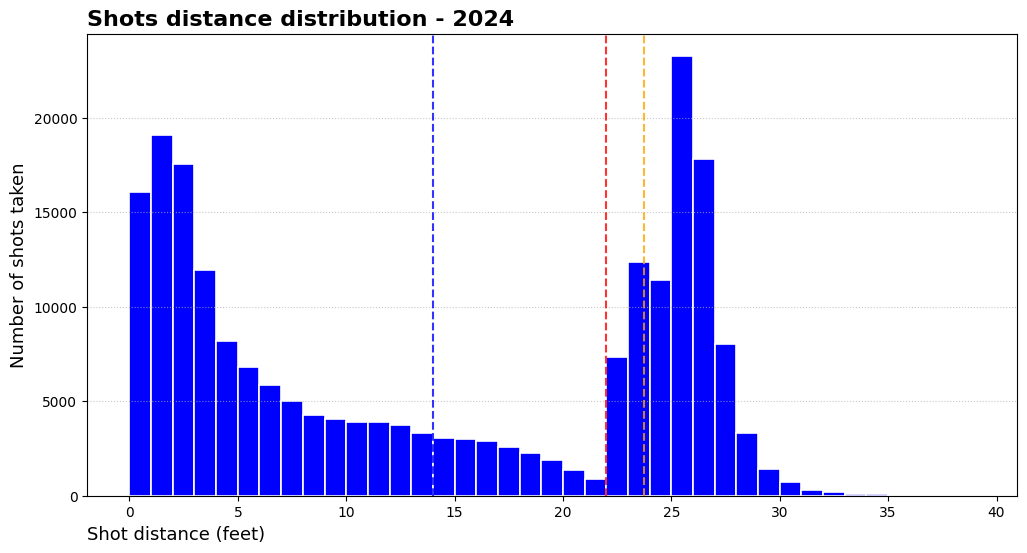

In [35]:
season = 2024

df = shots[
    (shots['SEASON_1'] == season) 
].copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df['SHOT_DISTANCE'], bins=range(0,40), color='blue', edgecolor='white', linewidth=1.2)

ax.set_title(f"Shots distance distribution - {season}", fontsize=16, fontweight='bold', loc="left")
ax.set_xlabel("Shot distance (feet)", fontsize=13, loc="left")
ax.set_ylabel("Number of shots taken", fontsize=13)

ax.axvline(22.0, color='red', linestyle='--', alpha=0.8, label='Corner three(22 feet)')
ax.axvline(23.75, color='orange', linestyle='--', alpha=0.8, label='Top of the key three (23.75 feet)')
ax.axvline(14, color='blue', linestyle='--', alpha=0.8, label='Midrange (dai 14 feet)')

ax.grid(axis='y', linestyle=':', alpha=0.7)

plt.show()

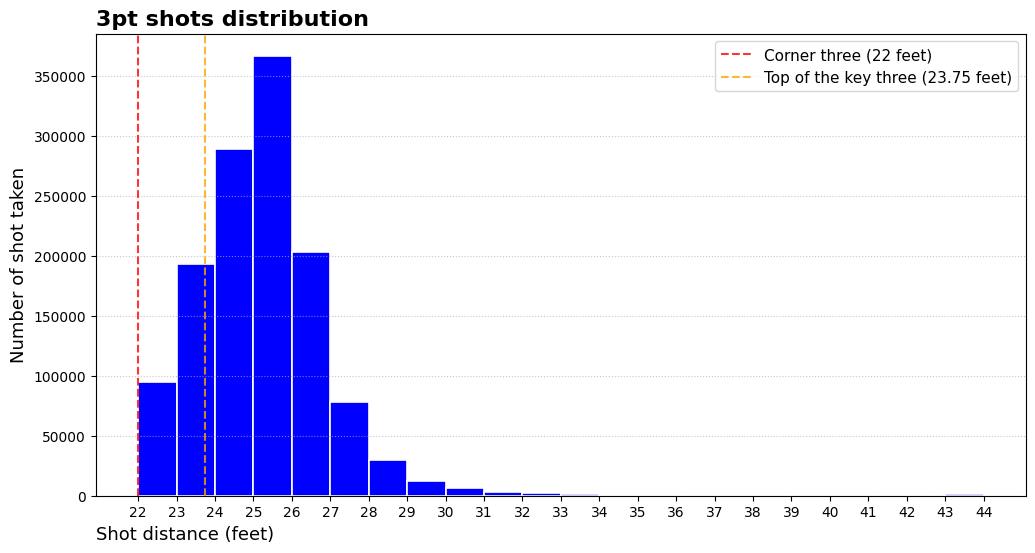

In [36]:
season = 2009

df = shots[
    (shots['SHOT_TYPE'] == '3PT Field Goal')
].copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df['SHOT_DISTANCE'], bins=range(22, 45), color='blue', edgecolor='white', linewidth=1.2)

ax.set_title(f"3pt shots distribution", fontsize=16, fontweight='bold', loc="left")
ax.set_xlabel("Shot distance (feet)", fontsize=13, loc="left")
ax.set_ylabel("Number of shot taken", fontsize=13)

ax.axvline(22.0, color='red', linestyle='--', alpha=0.8, label='Corner three (22 feet)')
ax.axvline(23.75, color='orange', linestyle='--', alpha=0.8, label='Top of the key three (23.75 feet)')

ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.set_xticks(range(22, 45))
ax.legend(loc='upper right', fontsize=11)

plt.show()

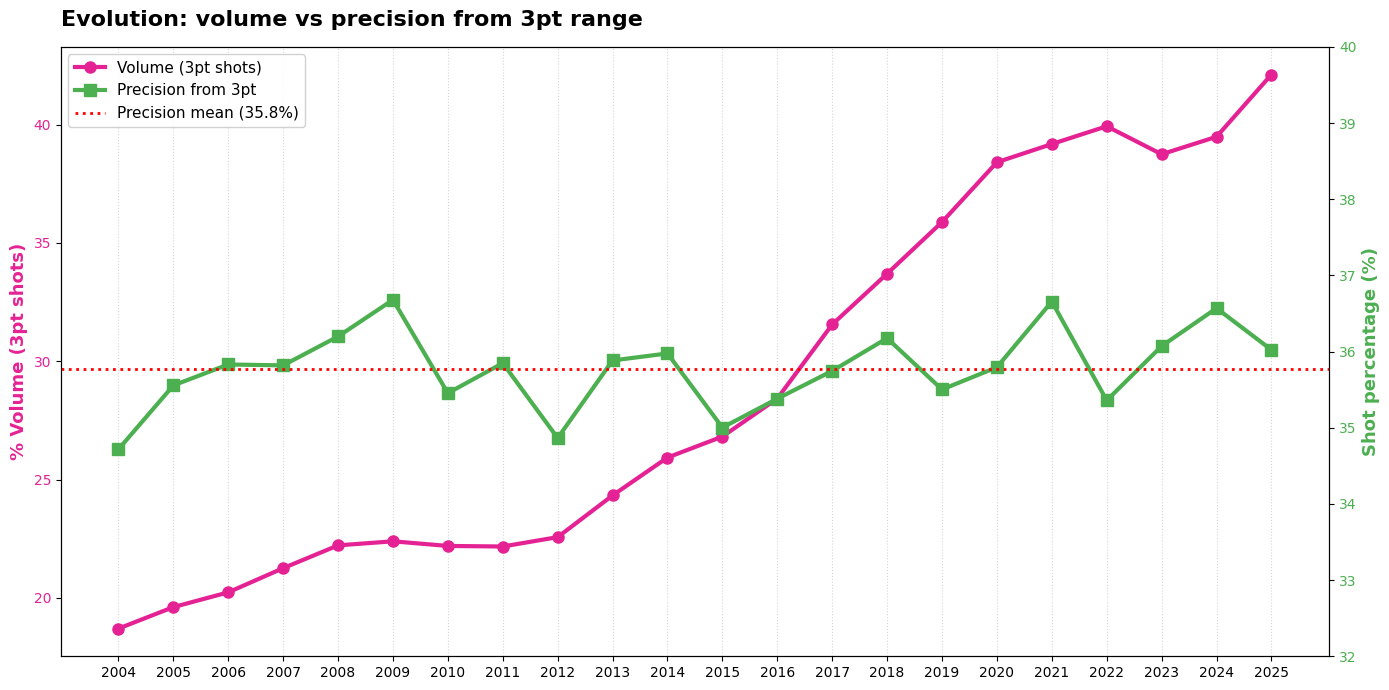

In [37]:
nshots = shots.groupby('SEASON_1').size() #df con numero di tiri PER ANNO grazie al groupby

threeptshots = shots[shots['SHOT_TYPE'] == '3PT Field Goal']
n3ptshots = threeptshots.groupby('SEASON_1').size()
nmade3ptshots = threeptshots.groupby('SEASON_1')['SHOT_MADE'].sum()

perc_volume = (n3ptshots / nshots) * 100
perc_precisione = (nmade3ptshots / n3ptshots) * 100
years = perc_volume.index #estrae gli anni, tutto quello che ho sono liste o tuple o comunque cose con tutti gli anni e le percentuali per anno o quantità per anno

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(years, perc_volume, marker='o', color="#e52294", linewidth=3, markersize=8, label="Volume (3pt shots)")

ax1.set_ylabel("% Volume (3pt shots)", fontsize=13, color="#e52294", fontweight='bold')
ax1.tick_params(axis='y', labelcolor="#e52294")
ax1.set_xticks(years)
ax1.grid(axis='x', linestyle=':', alpha=0.5) 

ax2 = ax1.twinx()

ax2.plot(years, perc_precisione, marker='s', color='#4caf50', linewidth=3, markersize=8, label="Precision from 3pt")

ax2.set_ylabel("Shot percentage (%)", fontsize=13, color="#4caf50", fontweight='bold')
ax2.tick_params(axis='y', labelcolor="#4caf50") 
ax2.set_ylim(32, 40) 


media_storica = perc_precisione.mean()
ax2.axhline(media_storica, color='red', linestyle=':', linewidth=2, label=f'Precision mean ({media_storica:.1f}%)')

plt.title("Evolution: volume vs precision from 3pt range", fontsize=16, fontweight='bold', loc='left', pad=15)
 
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

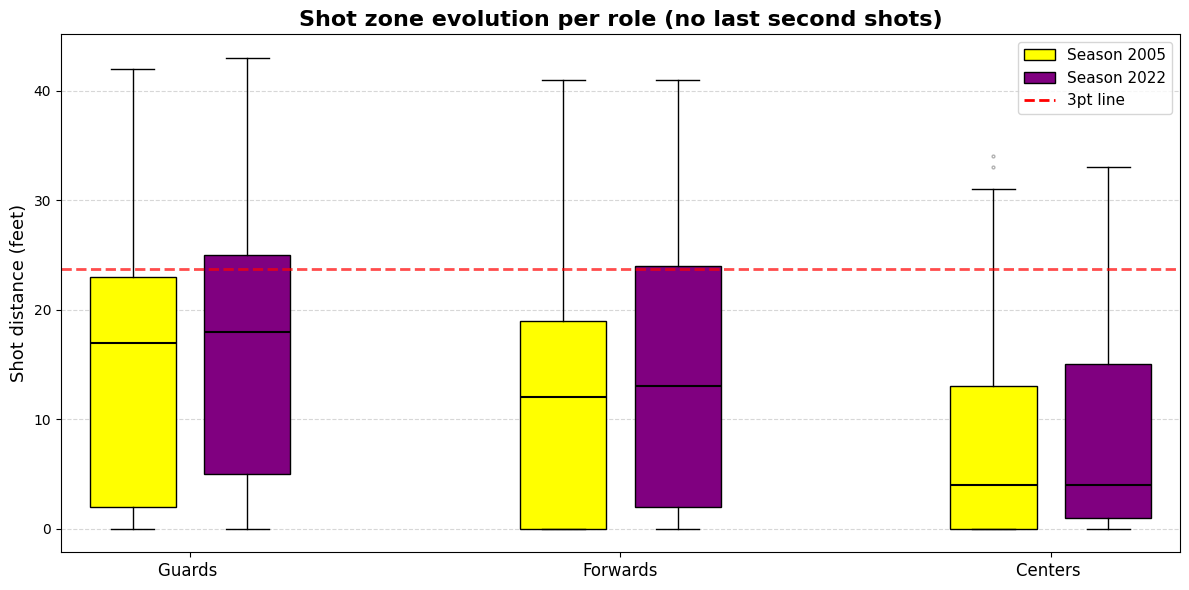

In [38]:
anno_passato = 2005
anno_recente = 2022
ruoli = ['G', 'F', 'C']
colore_passato = "yellow"
colore_recente = "purple"

df_box = shots[shots['SEASON_1'].isin([anno_passato, anno_recente])].copy()
df_box = df_box.dropna(subset=['SHOT_DISTANCE', 'POSITION_GROUP'])

df_box = df_box[df_box['SHOT_DISTANCE'] < 45]

df_box = df_box[~((df_box['MINS_LEFT'] == 0) & (df_box['SECS_LEFT'] < 5))]

dati_distanze = []
posizioni_box = []
colori_box = []
etichette_x = []

perc_totale_passato = []
perc_totale_recente = []

posizione_corrente = 1

for ruolo in ruoli:
    tiri_passato = df_box[(df_box['POSITION_GROUP'] == ruolo) & (df_box['SEASON_1'] == anno_passato)]
    dati_distanze.append(tiri_passato['SHOT_DISTANCE'].values)
    posizioni_box.append(posizione_corrente)
    colori_box.append(colore_passato)
    
    if len(tiri_passato) > 0:
        perc_totale_passato.append(tiri_passato['SHOT_MADE'].mean() * 100)
    else:
        perc_totale_passato.append(0)
    
    tiri_recente = df_box[(df_box['POSITION_GROUP'] == ruolo) & (df_box['SEASON_1'] == anno_recente)]
    dati_distanze.append(tiri_recente['SHOT_DISTANCE'].values)
    posizioni_box.append(posizione_corrente + 0.8)
    colori_box.append(colore_recente)

    if len(tiri_recente) > 0:
        perc_totale_recente.append(tiri_recente['SHOT_MADE'].mean() * 100)
    else:
        perc_totale_recente.append(0)
     
    etichette_x.append(posizione_corrente + 0.4)
    posizione_corrente += 3 


fig, ax1 = plt.subplots(figsize=(12, 6))

bplot = ax1.boxplot(
    dati_distanze, positions=posizioni_box, widths=0.6,
    patch_artist=True, flierprops=dict(marker='o', color='black', markersize=2, alpha=0.3)
)


for patch, color in zip(bplot['boxes'], colori_box):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')

for median in bplot['medians']:
    median.set_color('black')
    median.set_linewidth(1.5)

ax1.axhline(23.75, color='red', linestyle='--', alpha=0.7, linewidth=2)
ax1.set_xticks(etichette_x)

ax1.set_xticklabels(['Guards ', 'Forwards', 'Centers '], fontsize=12) 
ax1.set_title("Shot zone evolution per role (no last second shots)", fontsize=16, fontweight='bold')
ax1.set_ylabel("Shot distance (feet)", fontsize=13)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

elementi_legenda = [
    Patch(facecolor=colore_passato, edgecolor='black', label=f'Season {anno_passato}'),
    Patch(facecolor=colore_recente, edgecolor='black', label=f'Season {anno_recente}'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='3pt line')
]
ax1.legend(handles=elementi_legenda, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

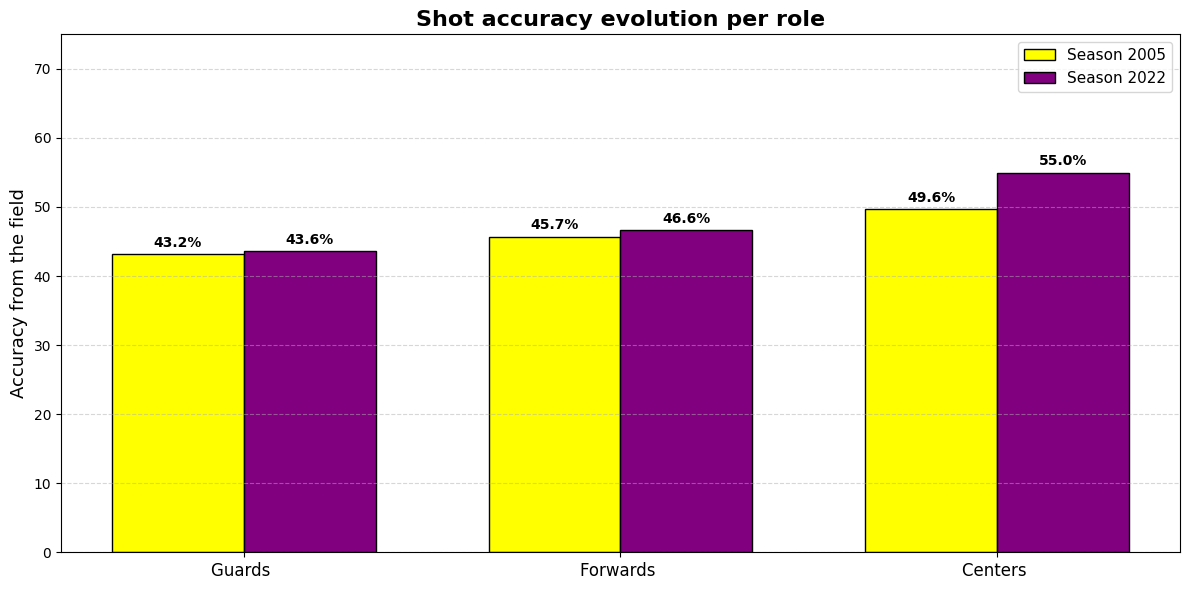

In [39]:
fig, ax2 = plt.subplots(figsize=(12, 6))

x_indici = np.arange(len(ruoli))
larghezza_barra = 0.35

barre1 = ax2.bar(x_indici - larghezza_barra/2, perc_totale_passato, larghezza_barra, color=colore_passato, edgecolor='black', label=f'Season {anno_passato}')
barre2 = ax2.bar(x_indici + larghezza_barra/2, perc_totale_recente, larghezza_barra, color=colore_recente, edgecolor='black', label=f'Season {anno_recente}')

def autolabel(barre):
    for rect in barre:
        altezza = rect.get_height()
        if altezza > 0:
            ax2.annotate(f'{altezza:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, altezza),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(barre1)
autolabel(barre2)

ax2.set_xticks(x_indici)
ax2.set_xticklabels(['Guards ', 'Forwards ', 'Centers '], fontsize=12)
ax2.set_ylabel("Accuracy from the field", fontsize=13)
ax2.set_title("Shot accuracy evolution per role", fontsize=16, fontweight='bold')
ax2.set_ylim(0, 75) 
ax2.grid(axis='y', linestyle='--', alpha=0.5)

ax2.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

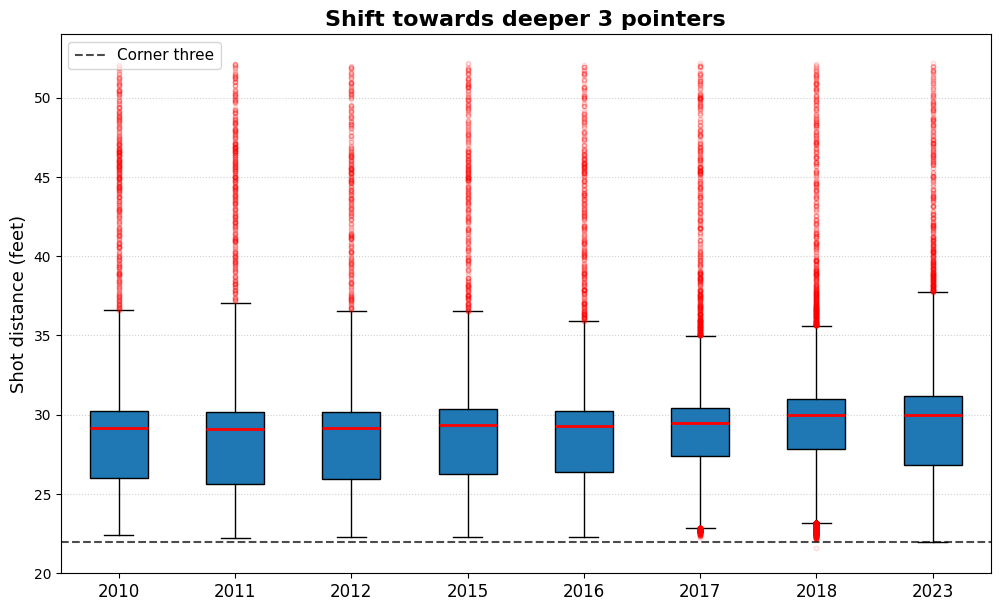

In [40]:
target_seasons = [2010, 2011, 2012,2015,2016, 2017, 2018, 2023]
dati_da_plottare = []

shots['EXACT_DISTANCE'] = np.sqrt(shots['LOC_X']**2 + shots['LOC_Y']**2) 

df_deep = shots[
    (shots['SHOT_TYPE'] == '3PT Field Goal') & 
    (shots['SEASON_1'].isin(target_seasons))
].copy()

for season in target_seasons:

    df_filtered = df_deep[(df_deep['SEASON_1'] == season) & 
                          (df_deep['SHOT_DISTANCE'] < 47) & 
                          (df_deep['SHOT_DISTANCE'] >1) & 
                          ~(df_deep['ACTION_TYPE'] == 'Right Corner 3') & 
                          ~(df_deep['ACTION_TYPE'] == 'Left Corner 3')]
    distanze = df_filtered['EXACT_DISTANCE'].values
        
    dati_da_plottare.append(distanze)

fig, ax = plt.subplots(figsize=(12, 7))

bplot = ax.boxplot(
    dati_da_plottare,
    patch_artist=True,
    widths=0.5,
    flierprops=dict(marker='o', color='red', markeredgecolor='red', markersize=3, alpha=0.15)
)


for median in bplot['medians']:
    median.set_color('red')
    median.set_linewidth(2)


ax.set_xticks(np.arange(1, len(target_seasons) + 1))
ax.set_xticklabels([f"{anno}" for anno in target_seasons], fontsize=12)

ax.set_title("Shift towards deeper 3 pointers", fontsize=16, fontweight='bold')
ax.set_ylabel("Shot distance (feet)", fontsize=13)

ax.axhline(22, color='black', linestyle='--', alpha=0.7, linewidth=1.5, label="Corner three")

ax.set_ylim(20, 54)

ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(loc='upper left', fontsize=11)

plt.show()

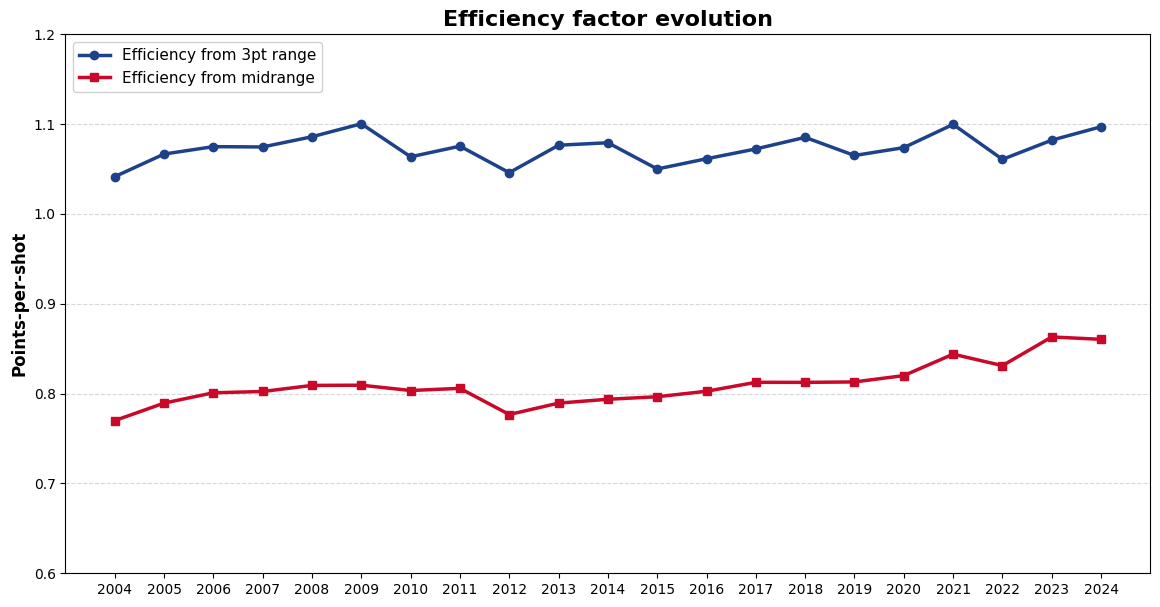

In [41]:
anni_analisi = range(2004, 2025)

df_base = shots[shots['SEASON_1'].isin(anni_analisi)]

mask_3pt = df_base['SHOT_TYPE'] == '3PT Field Goal'
mask_mid = (df_base['SHOT_TYPE'] != '3PT Field Goal') & (df_base['SHOT_DISTANCE'] > 10)

is_made = df_base['SHOT_MADE'].isin([True, 1, '1', 'Made Shot']).astype(int)

eff_3pt = is_made[mask_3pt].groupby(df_base.loc[mask_3pt, 'SEASON_1']).mean() * 3
eff_mid = is_made[mask_mid].groupby(df_base.loc[mask_mid, 'SEASON_1']).mean() * 2

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.plot(eff_3pt.index, eff_3pt.values, color='#1d428a', marker='o', linewidth=2.5, label='Efficiency from 3pt range')
ax1.plot(eff_mid.index, eff_mid.values, color='#c9082a', marker='s', linewidth=2.5, label='Efficiency from midrange')

ax1.set_ylabel('Points-per-shot', fontsize=12, fontweight='bold', color='black')
ax1.set_ylim(0.6, 1.2) 
ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.title("Efficiency factor evolution", fontsize=16, fontweight='bold')

ax1.legend(loc='upper left', fontsize=11, framealpha=0.9)

ax1.set_xticks(anni_analisi)


plt.show()

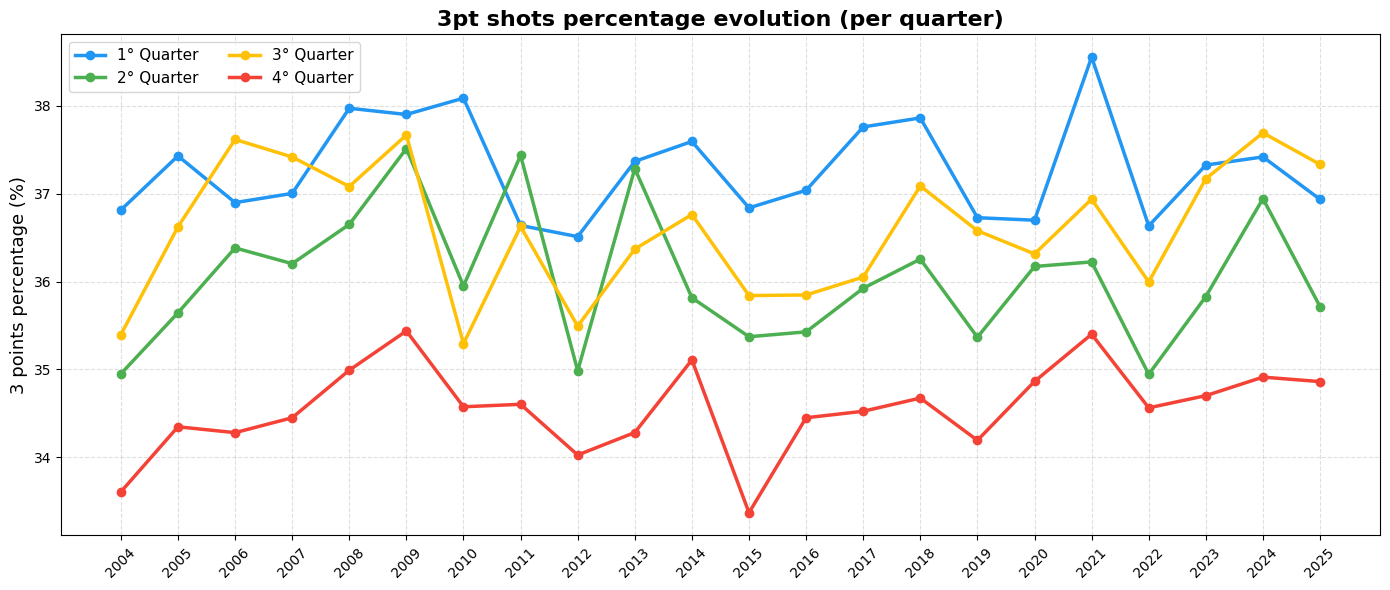

In [42]:
df_fatigue_3pt = shots[
    (shots['QUARTER'].isin([1, 2, 3, 4])) & 
    (shots['SHOT_TYPE'] == '3PT Field Goal')
].copy()

df_fatigue_3pt = df_fatigue_3pt[df_fatigue_3pt['SHOT_DISTANCE'] < 45]

fatigue_stats_3pt = df_fatigue_3pt.groupby(['SEASON_1', 'QUARTER']).agg(
    FG3_PCT=('SHOT_MADE', lambda x: x.mean() * 100),
    AVG_DIST=('SHOT_DISTANCE', 'mean')
).reset_index()

fg3_pivot = fatigue_stats_3pt.pivot(index='SEASON_1', columns='QUARTER', values='FG3_PCT')
dist3_pivot = fatigue_stats_3pt.pivot(index='SEASON_1', columns='QUARTER', values='AVG_DIST')
years_3pt = fg3_pivot.index

colori_quarti = {1: '#2196F3', 2: '#4CAF50', 3: '#FFC107', 4: '#F44336'}
labels_quarti = {1: '1° Quarter', 2: '2° Quarter', 3: '3° Quarter', 4: '4° Quarter'}

fig, ax1 = plt.subplots(figsize=(14, 6))

for q in [1, 2, 3, 4]:
    ax1.plot(years_3pt, fg3_pivot[q], marker='o', markersize=6, linewidth=2.5, 
             color=colori_quarti[q], label=labels_quarti[q])

ax1.set_ylabel("3 points percentage (%)", fontsize=13)
ax1.set_title("3pt shots percentage evolution (per quarter)", fontsize=16, fontweight='bold')
ax1.grid(axis='both', linestyle='--', alpha=0.4)
ax1.legend(loc='upper left', fontsize=11, ncol=2)

ax1.set_xticks(years_3pt)
ax1.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

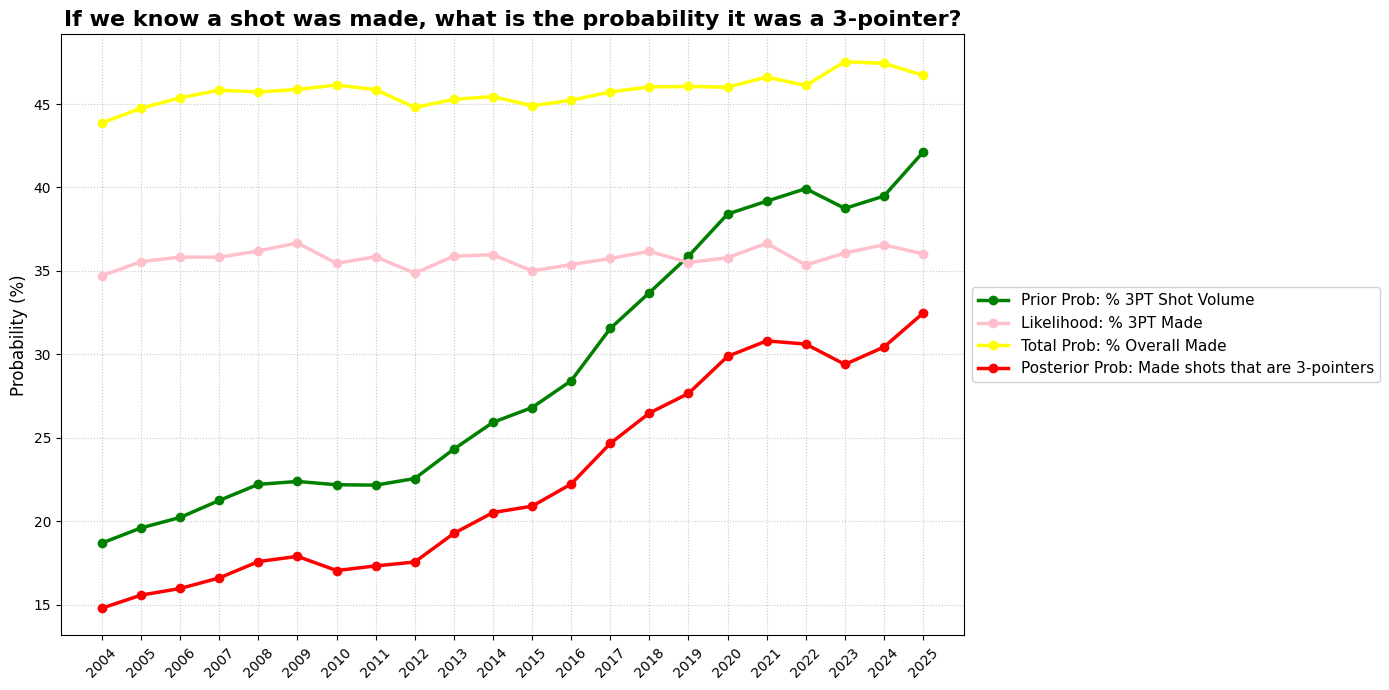

In [43]:
total_att = shots.groupby('SEASON_1').size()
total_made = shots[shots['SHOT_MADE'] == True].groupby('SEASON_1').size()
att_3pt = shots[shots['SHOT_TYPE'] == '3PT Field Goal'].groupby('SEASON_1').size()

made_3pt = shots[
    (shots['SHOT_TYPE'] == '3PT Field Goal') & 
    (shots['SHOT_MADE'].isin([True, 1, '1', 'Made Shot']))
].groupby('SEASON_1').size()

# prior: probabilità a priori che un tiro preso sia da 3
prior = att_3pt / total_att
# likelihood: probabilità di segnare sapendo che tira da 3 (FG% da 3)
likelihood = made_3pt / att_3pt
# marginal: percentuale dal campo totale (FG% globale)
marginal = total_made / total_att
# posterior: probabilità inversa (quanto pesano i canestri da 3 sui canestri totali)
posterior = (likelihood * prior) / marginal

fig, ax = plt.subplots(figsize=(14, 7)) 
ax.plot(prior.index, prior.values * 100, 
        color='green', linewidth=2.5, marker='o', markersize=6,
        label='Prior Prob: % 3PT Shot Volume')

ax.plot(likelihood.index, likelihood.values * 100, 
        color='pink', linewidth=2.5, marker='o', markersize=6,
        label='Likelihood: % 3PT Made')

ax.plot(marginal.index, marginal.values * 100, 
        color='yellow', linewidth=2.5, marker='o', markersize=6,
        label='Total Prob: % Overall Made')

ax.plot(posterior.index, posterior.values * 100, 
        color='red', linewidth=2.5, marker='o', markersize=6, 
        label='Posterior Prob: Made shots that are 3-pointers')

ax.set_title("If we know a shot was made, what is the probability it was a 3-pointer?", 
             fontsize=16, fontweight='bold')
ax.set_ylabel('Probability (%)', fontsize=12)

ax.grid(axis='both', linestyle=':', alpha=0.7)
ax.set_xticks(prior.index)
plt.xticks(rotation=45)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()